# 02 Exploratory Data Analysis


In [1]:
!pip install pandas matplotlib seaborn

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
import glob

In [4]:
path = "../data/processed/data_11-03_10-04"
all_files = glob.glob(os.path.join(path, "*.csv"))

all_files

['../data/processed/data_11-03_10-04/data_session_15_2026-04-02_10-28_to_2026-04-04_16-57.csv',
 '../data/processed/data_11-03_10-04/data_session_1_2026-03-12_15-38_to_2026-03-14_15-57.csv',
 '../data/processed/data_11-03_10-04/data_session_8_2026-03-21_18-10_to_2026-03-22_14-44.csv',
 '../data/processed/data_11-03_10-04/data_session_17_2026-04-07_07-42_to_2026-04-10_09-16.csv',
 '../data/processed/data_11-03_10-04/data_session_14_2026-03-31_15-00_to_2026-04-02_09-06.csv',
 '../data/processed/data_11-03_10-04/data_session_13_2026-03-25_09-31_to_2026-03-31_14-28.csv',
 '../data/processed/data_11-03_10-04/data_session_5_2026-03-20_03-25_to_2026-03-21_06-10.csv',
 '../data/processed/data_11-03_10-04/data_session_16_2026-04-04_19-45_to_2026-04-07_03-51.csv',
 '../data/processed/data_11-03_10-04/data_session_12_2026-03-23_14-22_to_2026-03-25_08-57.csv',
 '../data/processed/data_11-03_10-04/data_session_2_2026-03-14_22-50_to_2026-03-16_04-48.csv',
 '../data/processed/data_11-03_10-04/data_se

In [7]:
dict_sessions = {}

for file in all_files:
    file_name = os.path.basename(file)
    session_id = int(file_name.split('_')[2])
    
    # Read the CSV make sure our index is the timestamp
    df = pd.read_csv(file, index_col='timestamp', parse_dates=True)
    
    dict_sessions[session_id] = df

sorted_keys = sorted(dict_sessions.keys())

print(f"{len(dict_sessions)} sessions loaded")
print(f"Session IDs: {sorted_keys}")

11 sessions loaded
Session IDs: [1, 2, 3, 5, 8, 12, 13, 14, 15, 16, 17]


In [8]:
TAG_INFO = {
    "FT-201": {"label": "Biogas inlet flow", "unit": "Nm3/h"},
    "FT-801": {"label": "Biomethane outlet flow", "unit": "Nm3/h"},
    "FT-901": {"label": "Exhaust gas flow", "unit": "Nm3/h"},
    "Mode": {"label": "Run mode", "unit": "integer"},
    "PT-901": {"label": "Gas line inlet vacuum pressure", "unit": "bar"},
    "PT-902": {"label": "Gas line outlet vacuum pressure", "unit": "bar"},
    "PT-903": {"label": "Vacuum pressure in oil separator", "unit": "bar"},
    "TT-901": {"label": "Oil separator gas temperature", "unit": "°C"},
    "TT-902": {"label": "Discharge 1 temperature", "unit": "°C"},
    "TT-903": {"label": "Discharge 2 temperature", "unit": "°C"},
    "TT-904": {"label": "Oil temperature", "unit": "°C"},
    "VSD-901_CORRENT": {"label": "Vacuum pump current", "unit": "A"},
    "VSD-901_POWER": {"label": "Vacuum pump power", "unit": "W"},
    "VSD-901_RPM": {"label": "Vacuum pump rotation", "unit": "RPM"},
    "VSD-901_SPEED": {"label": "Vacuum pump speed", "unit": "%"},
    "LS-901": {"label": "Oil level sensor", "unit": "true/false"},
}

pressure_cols = ["PT-901", "PT-902", "PT-903"]
temp_cols = ["TT-901", "TT-902", "TT-903", "TT-904"]
flow_cols = ["FT-201", "FT-801", "FT-901"]

pump_oil_level_cols = ["LS-901"]
pump_current_cols = ["VSD-901_CORRENT"]
pump_power_cols = ["VSD-901_POWER"]
pump_rpm_cols = ["VSD-901_RPM"]
pump_speed_cols = ["VSD-901_SPEED"]

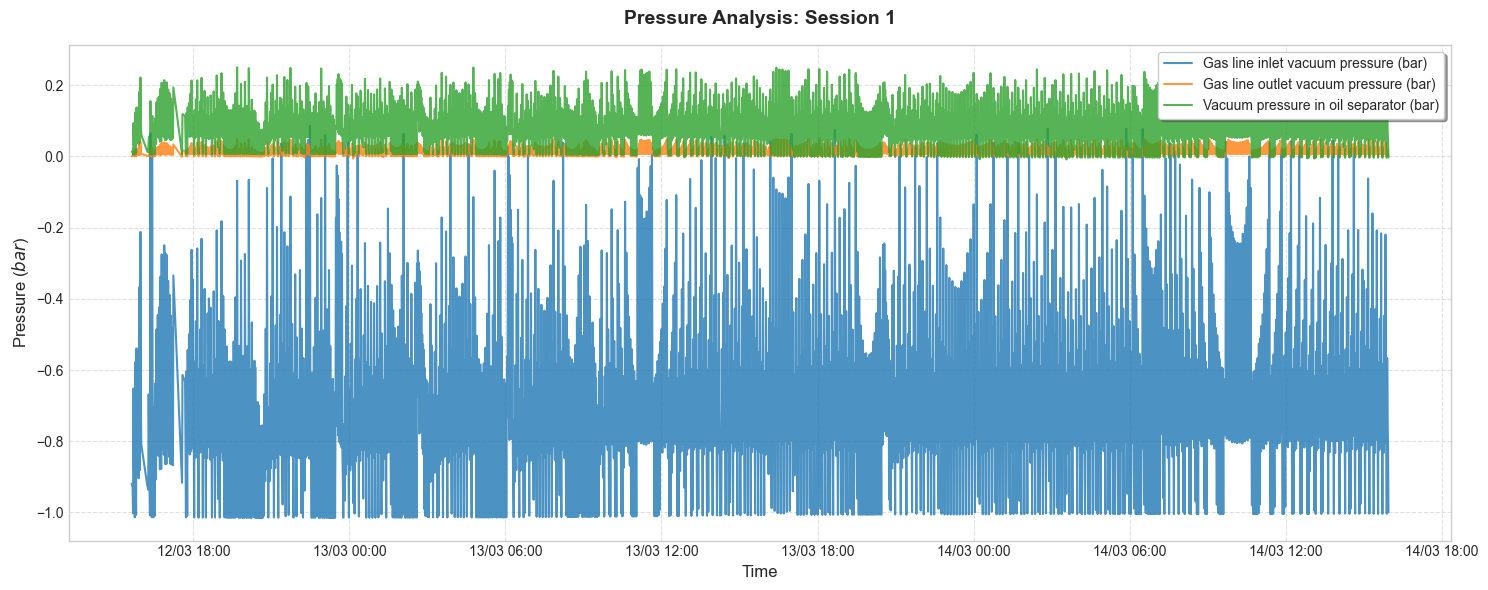

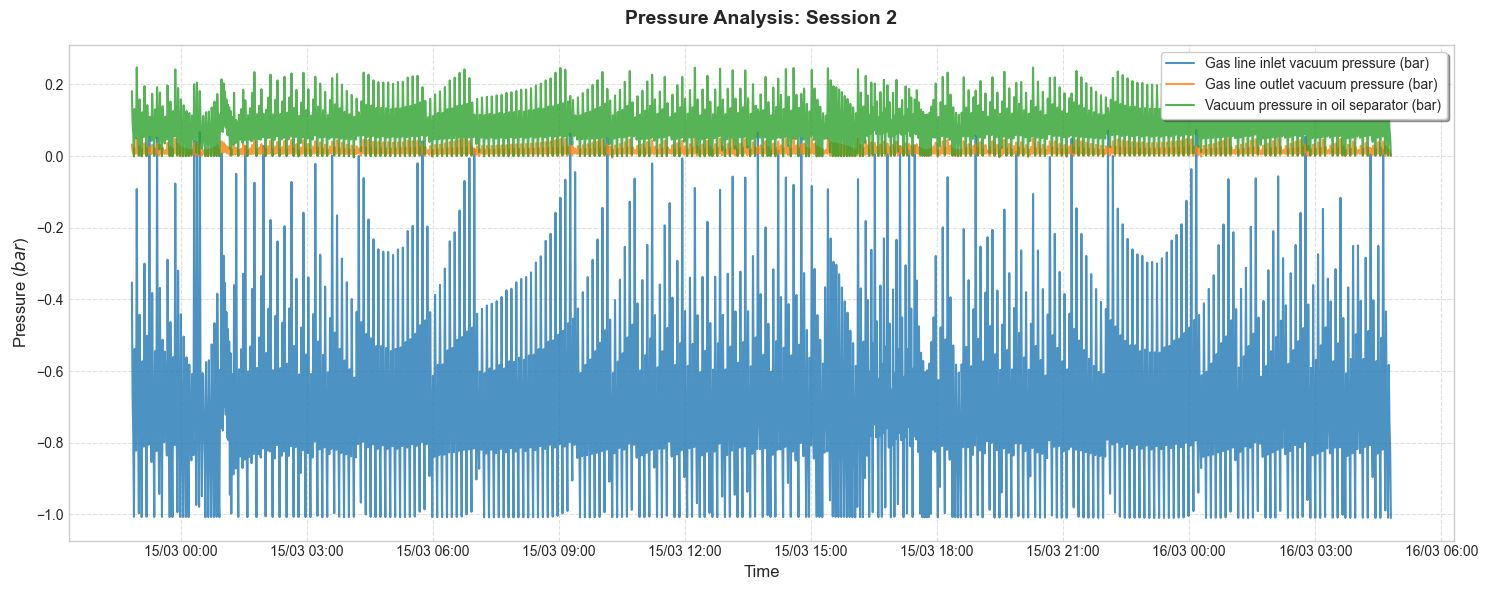

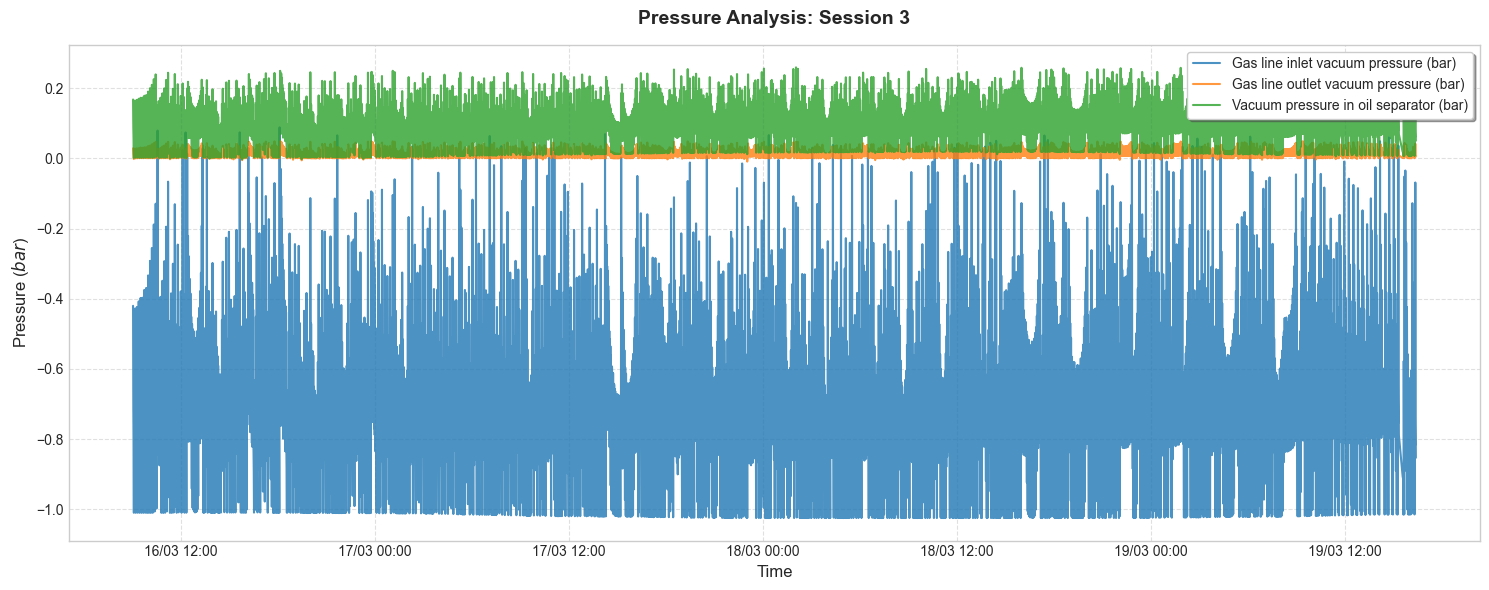

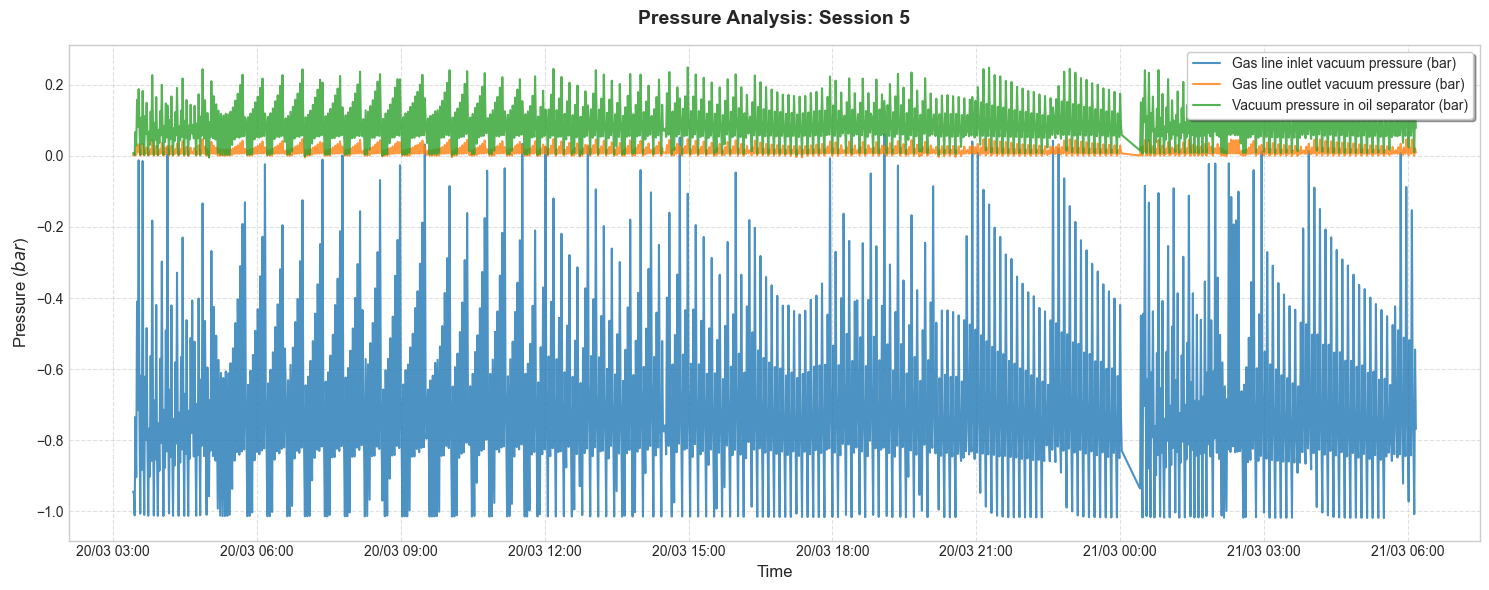

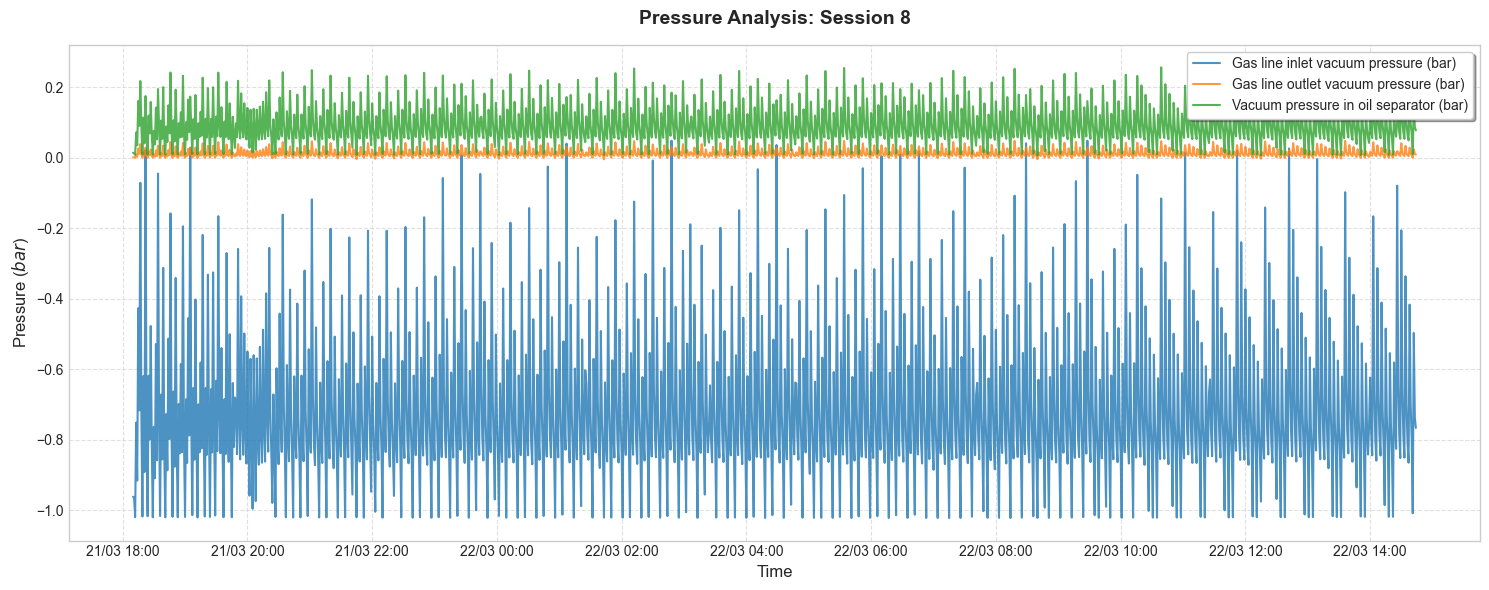

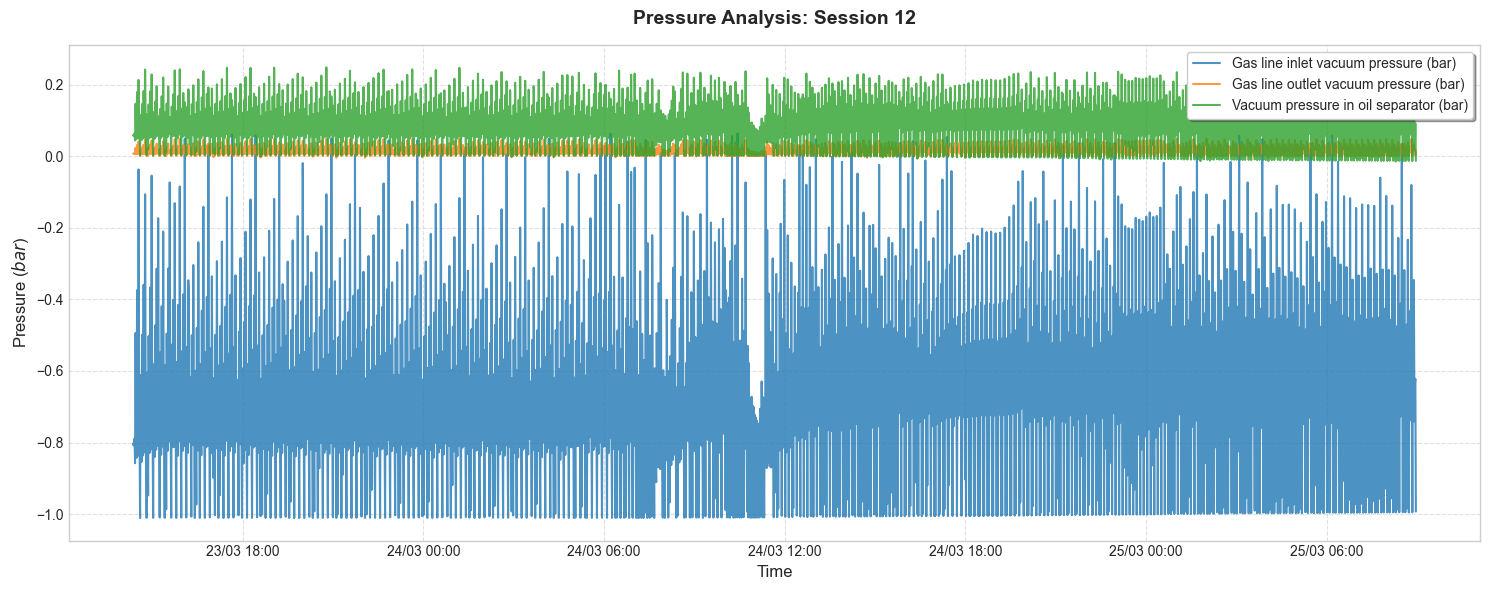

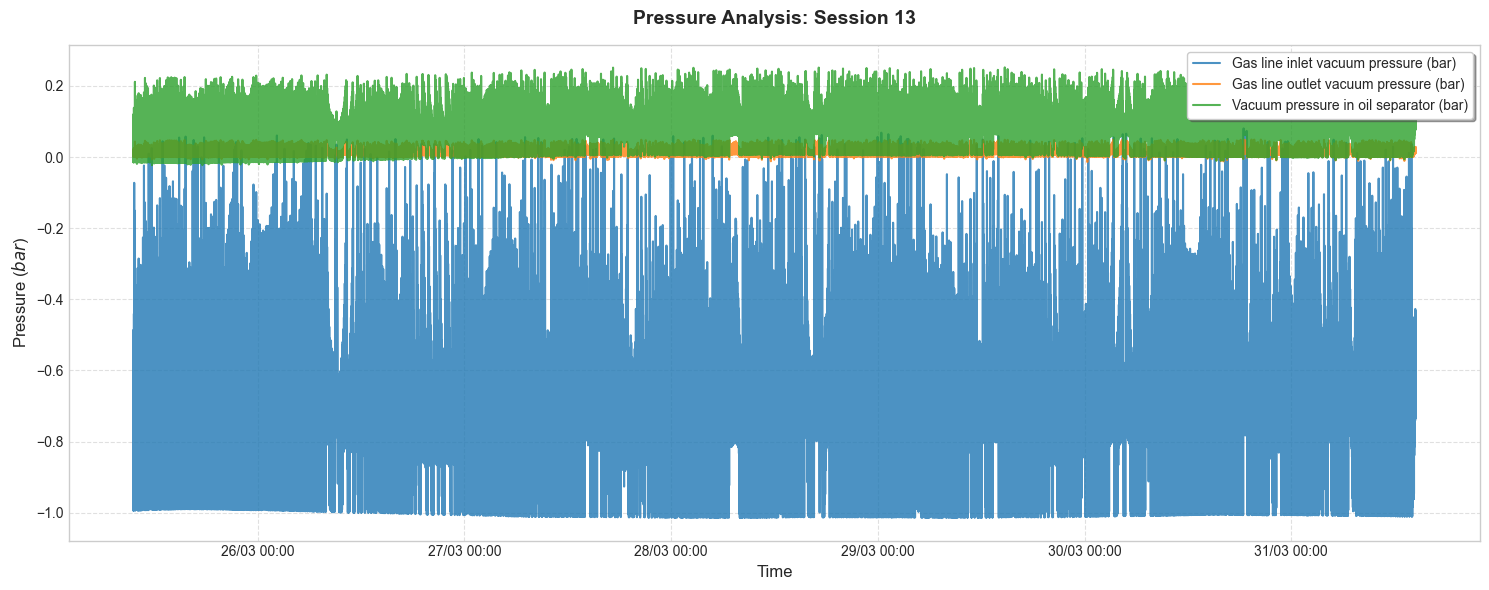

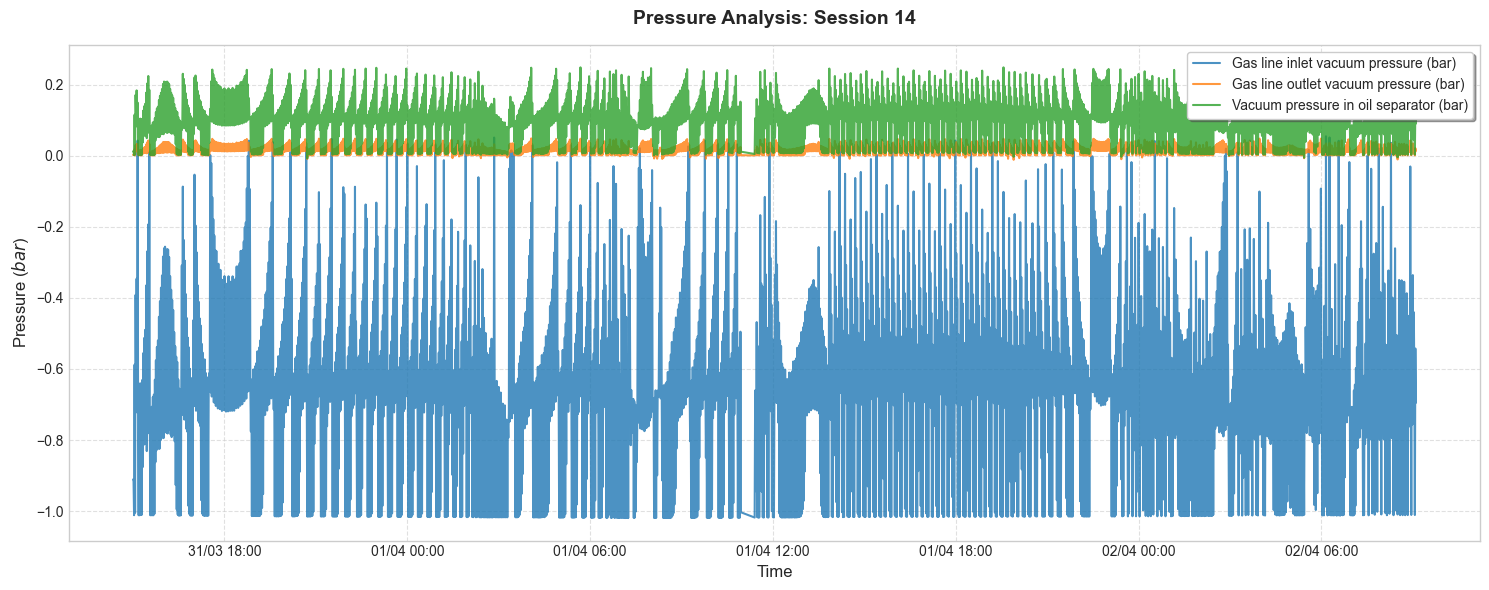

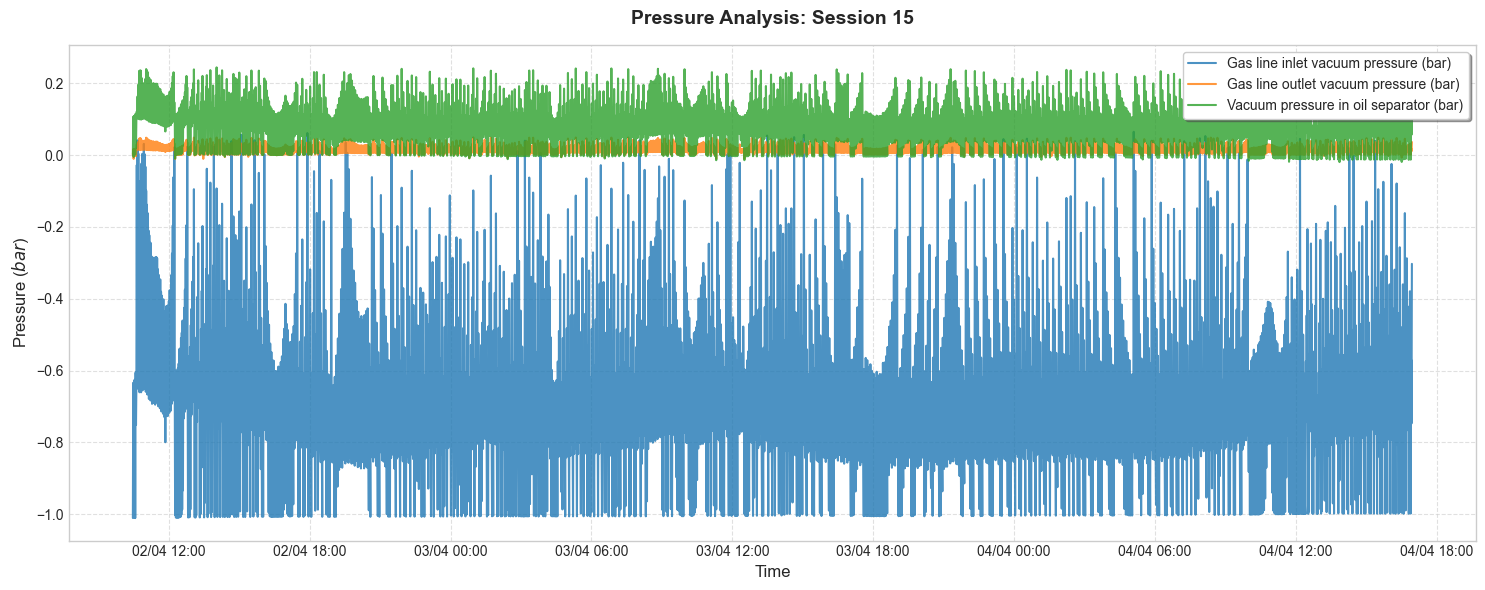

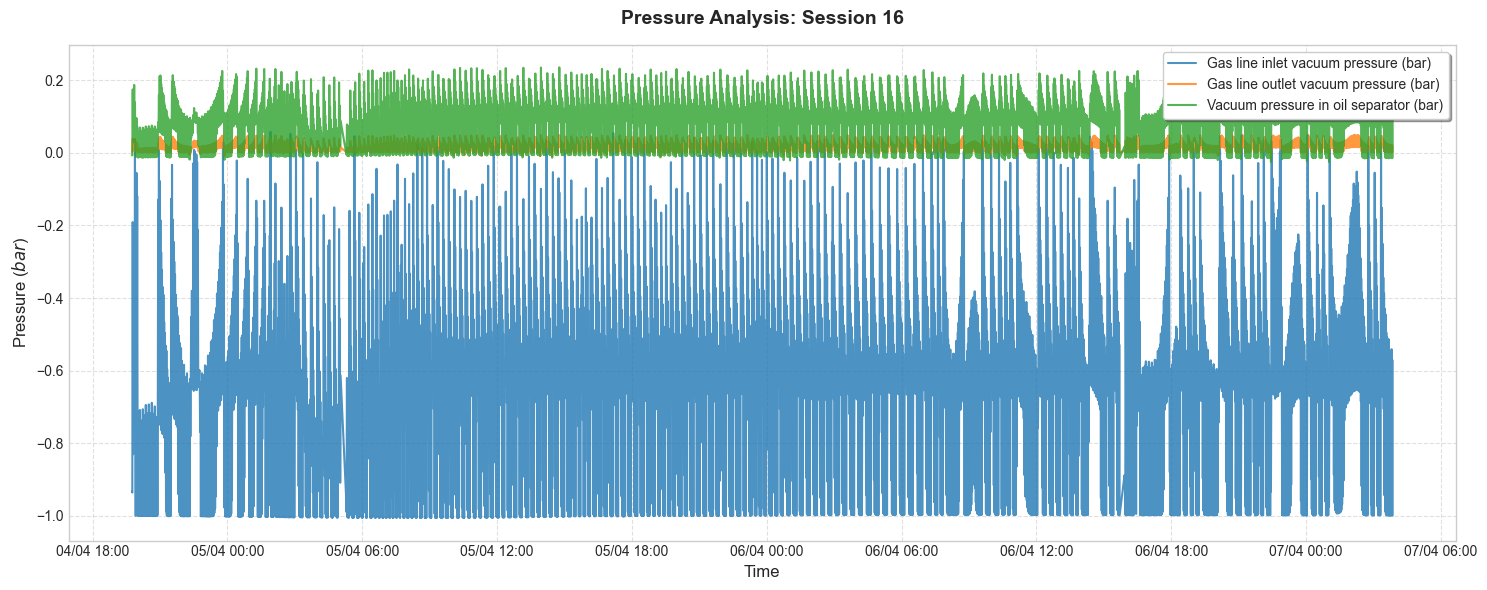

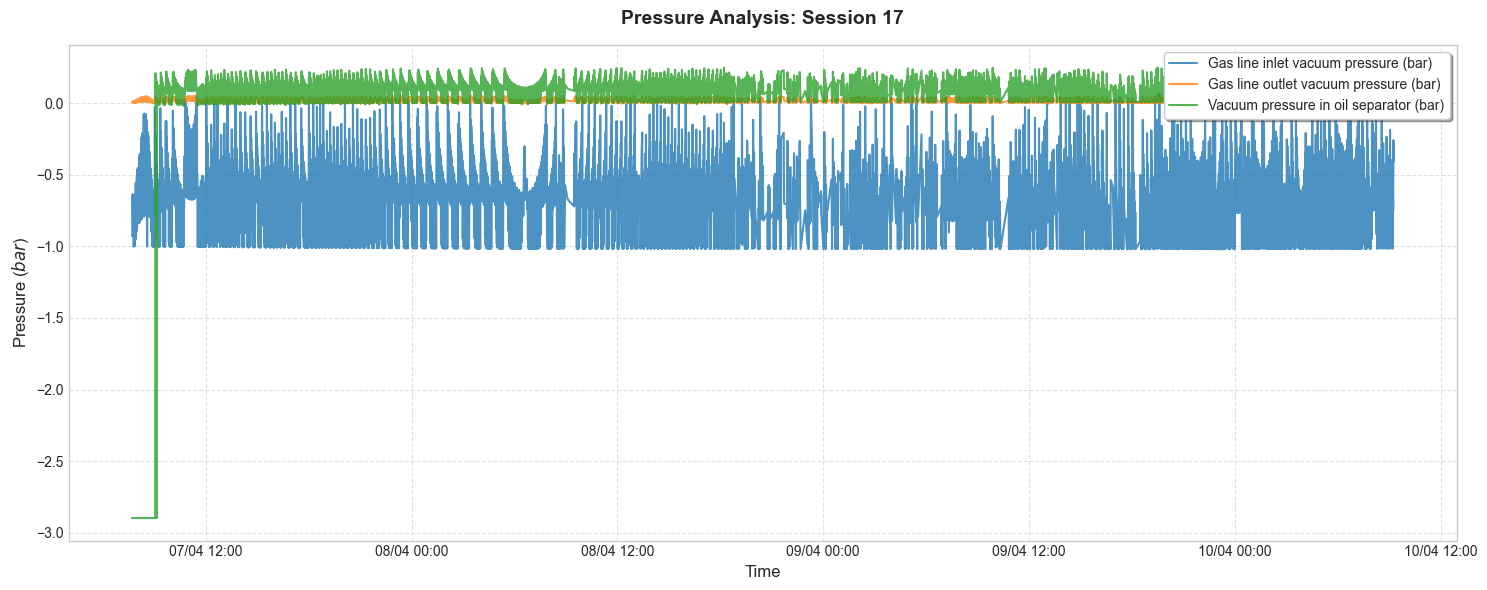

In [11]:
# Configurar o estilo visual
plt.style.use('seaborn-v0_8-whitegrid')

# Iterar sobre as sessões carregadas (ordenadas por ID)
for s_id in sorted(dict_sessions.keys()):
    df = dict_sessions[s_id]
    
    # Criar a figura
    fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
    
    # Plotar as 3 colunas de pressão
    for col in pressure_cols:
        label_text = f"{TAG_INFO[col]['label']} ({TAG_INFO[col]['unit']})"
        ax.plot(df.index, df[col], label=label_text, linewidth=1.5, alpha=0.8)
    
    # Personalização do gráfico
    ax.set_title(f"Pressure Analysis: Session {s_id}", fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel("Pressure ($bar$)", fontsize=12)
    ax.set_xlabel("Time", fontsize=12)
    
    # Formatação do eixo do tempo (Dia/Mês Hora:Minuto)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
    
    # Adicionar legenda e grelha
    ax.legend(loc='upper right', frameon=True, facecolor='white', shadow=True)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    
    # Opcional: Salvar cada gráfico automaticamente
    # plt.savefig(f"pressure_profile_session_{s_id}.png")
    
    plt.show()